In [11]:
import pandas as pd
df = pd.read_csv(
                    '../data/raw/FEK_download.csv',
                     encoding='utf-8',
                     skiprows=1
                     )
print(df.shape)

(2129, 3)


In [12]:
df.head()

,分類コード,項目名,項目の説明
0,,※キーワード検索機能（検索オプション機能を使わない場合）は、検索するキーワードが「項目名」、...,NaN
1,A,農業、林業,総 説\r\n この大分類には、耕種農業、畜産農業（養きん、養ほう、養蚕を含む）及び農業...
2,01,農業,総 説\r\n この中分類には、耕種農業、畜産農業（養きん、養ほう、養蚕を含む）及び農業...
3,010,管理、補助的経済活動を行う事業所（01農業）,NaN
4,0100,主として管理事務を行う本社等,主として農業の事業所を統括する本社等として、自企業の経営を推進するための組織全体の管理統括業...


★「項目の説明」のない小分類を落とす

In [13]:
df = df.dropna()
df.shape

(1597, 3)

In [14]:
df["項目の説明"] = df["項目の説明"].str.replace(r'総　　　説','総説')
df["項目の説明"] = df["項目の説明"].str.replace(r'[\r\n\u3000]+',' ', regex=True).str.strip()
df = df.reset_index(drop=True)
df.head()


ArrowInvalid: Invalid regular expression: invalid escape sequence: \u

In [ ]:
df.to_csv("../data/processed/FEK_download_clns.csv",index=False)

In [ ]:
df = pd.read_csv("../data/processed/FEK_download_clns.csv")
df.head()

,分類コード,項目名,項目の説明
0,A,農業、林業,総説 この大分類には、耕種農業、畜産農業（養きん、養ほう、養蚕を含む）及び農業に直接関係する...
1,01,農業,総説 この中分類には、耕種農業、畜産農業（養きん、養ほう、養蚕を含む）及び農業に直接関係する...
2,0100,主として管理事務を行う本社等,主として農業の事業所を統括する本社等として、自企業の経営を推進するための組織全体の管理統括業...
3,0109,その他の管理、補助的経済活動を行う事業所,主として農業における活動を促進するため、同一企業の他事業所に対して、輸送、清掃、修理・整備、...
4,0111,米作農業,主として米（水稲、陸稲）を栽培し、出荷する事業所をいう。


In [ ]:
#大分類だけ抜き出す
mask = df['分類コード'].str.match(r'^[a-zA-Z]+$', na=False)
df[mask]

,分類コード,項目名,項目の説明
0,A,農業、林業,総説 この大分類には、耕種農業、畜産農業（養きん、養ほう、養蚕を含む）及び農業に直接関係する...
37,B,漁業,総説 この大分類には、海面又は内水面において自然繁殖している水産動植物を採捕する事業所、海面...
62,C,鉱業、採石業、砂利採取業,総説 この大分類には、有機物、無機物を問わず、天然に固体、液体又はガスの状態で生ずる鉱物を掘...
96,D,建設業,総説 この大分類には、主として注文又は自己建設によって建設工事を施工する事業所が分類される。...
155,E,製造業,総説 この大分類には、有機又は無機の物質に物理的、化学的変化を加えて新たな製品を製造し、これ...
782,F,電気・ガス・熱供給・水道業,総説 この大分類には、電気、ガス、熱又は水（かんがい用水を除く）を供給する事業所並びに汚水・...
807,G,情報通信業,総説 この大分類には、情報の伝達を行う事業所、情報の処理、提供などのサービスを行う事業所、イ...
858,H,運輸業、郵便業,総説 この大分類には、鉄道、自動車、船舶、航空機又はその他の運送用具による旅客、貨物の運送業...
930,I,卸売業、小売業,総説 この大分類には、原則として、有体的商品を購入して販売する事業所が分類される。 なお、販...
1148,J,金融業、保険業,総説 この大分類には、金融業又は保険業を営む事業所が分類される。 専ら金融又は保険の事業を営...


In [ ]:
#中分類だけ抜き出す
mask = df['分類コード'].str.match(r'^\d{2}$', na=False)
df[mask]

,分類コード,項目名,項目の説明
1,01,農業,総説 この中分類には、耕種農業、畜産農業（養きん、養ほう、養蚕を含む）及び農業に直接関係する...
24,02,林業,総説 この中分類には、山林用苗木の育成・植栽、林木の保育・保護、林木からの素材生産、薪及び木...
38,03,漁業（水産養殖業を除く）,総説 この中分類には、海面又は内水面において自然繁殖している（まき付、放苗、投石、耕うんなど...
51,04,水産養殖業,総説 この中分類には、海面又は内水面において人工的設備を施し、水産動植物を移植、放苗、育成...
63,05,鉱業、採石業、砂利採取業,総説 この中分類には、有機物、無機物を問わず、天然に固体、液体又はガスの状態で生ずる鉱物...
...,...,...,...
1579,95,その他のサービス業,総説 この中分類には、他に分類されないサービスを提供する事業所が分類される。
1584,96,外国公務,総説 この中分類には、日本国内に駐在する外国政府及び国際機関などの事業所が分類される。
1588,97,国家公務,総説 この中分類には、国の機関のうち、国会、裁判所、行政機関及びその地方支分部局などにおいて...
1592,98,地方公務,総説 この中分類には、地方公共団体の機関のうち、都道府県庁、市役所、町村役場、地方公共団体の...


In [ ]:
df.head()

,分類コード,項目名,項目の説明
0,A,農業、林業,総説 この大分類には、耕種農業、畜産農業（養きん、養ほう、養蚕を含む）及び農業に直接関係する...
1,01,農業,総説 この中分類には、耕種農業、畜産農業（養きん、養ほう、養蚕を含む）及び農業に直接関係する...
2,0100,主として管理事務を行う本社等,主として農業の事業所を統括する本社等として、自企業の経営を推進するための組織全体の管理統括業...
3,0109,その他の管理、補助的経済活動を行う事業所,主として農業における活動を促進するため、同一企業の他事業所に対して、輸送、清掃、修理・整備、...
4,0111,米作農業,主として米（水稲、陸稲）を栽培し、出荷する事業所をいう。


In [5]:
df = pd.read_csv("industry_master_33_boosted.csv")
df.head()

,業種名,業種説明
0,水産・農林業,水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農...
1,鉱業,鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱...
2,建設業,建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設...
3,食料品,食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料...
4,繊維製品,繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊...


In [ ]:
from processor.word_process import sudachi_tokenize
df["nouns"] = df["業種説明"].apply(sudachi_tokenize)
df.head()

,業種名,業種説明,nouns
0,水産・農林業,水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農...,水産 農林業 水産 農林業 水産 農林業 水産 農林業 水産 農林業 水産 農林業 水産 農...
1,鉱業,鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱...,鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱...
2,建設業,建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設...,建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設...
3,食料品,食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料...,食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料...
4,繊維製品,繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊...,繊維 製品 繊維 製品 繊維 製品 繊維 製品 繊維 製品 繊維 製品 繊維 製品 繊維 製...


In [7]:
from collections import Counter
all_words = " ".join(df["nouns"]).split()


common_words = Counter(all_words).most_common(50)
rare_words = Counter(all_words).most_common()[:-11:-1]
for word, count in common_words:
    print(f"{word}: {count}")
#for word, count in rare_words:
    #print(f"{word}: {count}")


製品: 125
金属: 45
電気: 41
機械: 28
水産: 22
運輸: 22
鉱業: 21
石油: 21
食料品: 21
パルプ: 21
化学: 21
医薬品: 21
ゴム: 21
土石: 21
非鉄: 21
機器: 21
ガス業: 21
卸売業: 21
小売業: 21
農林業: 20
建設業: 20
繊維: 20
石炭: 20
ガラス: 20
鉄鋼: 20
輸送用機器: 20
精密機器: 20
陸運業: 20
海運業: 20
空運業: 20
倉庫: 20
関連: 20
情報: 20
通信業: 20
銀行業: 20
証券: 20
商品先物取引: 20
保険業: 20
金融業: 20
不動産業: 20
サービス業: 20
製造業: 6
運送: 4
器具: 3
建設: 2
プラスチック: 2
船舶: 2
供給: 2
サービス: 2
各種: 2


In [8]:
##業種定義のユニークな名詞の数=setを使おう
##業種定義のヌルユニークな名詞の数=listを使おう
all_unique_words = set(all_words)
all_nunique_words = list(all_words)
print(f"全業種の定義に含まれるユニークな名詞の数: {len(all_unique_words)}語")
print(f"全業種の定義に含まれるヌルユニークな名詞の数: {len(all_nunique_words)}語")

全業種の定義に含まれるユニークな名詞の数: 276語
全業種の定義に含まれるヌルユニークな名詞の数: 1249語


/tmp/ipykernel_302425/561287438.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(plot_data['word'], fontproperties=font_prop, rotation=90)


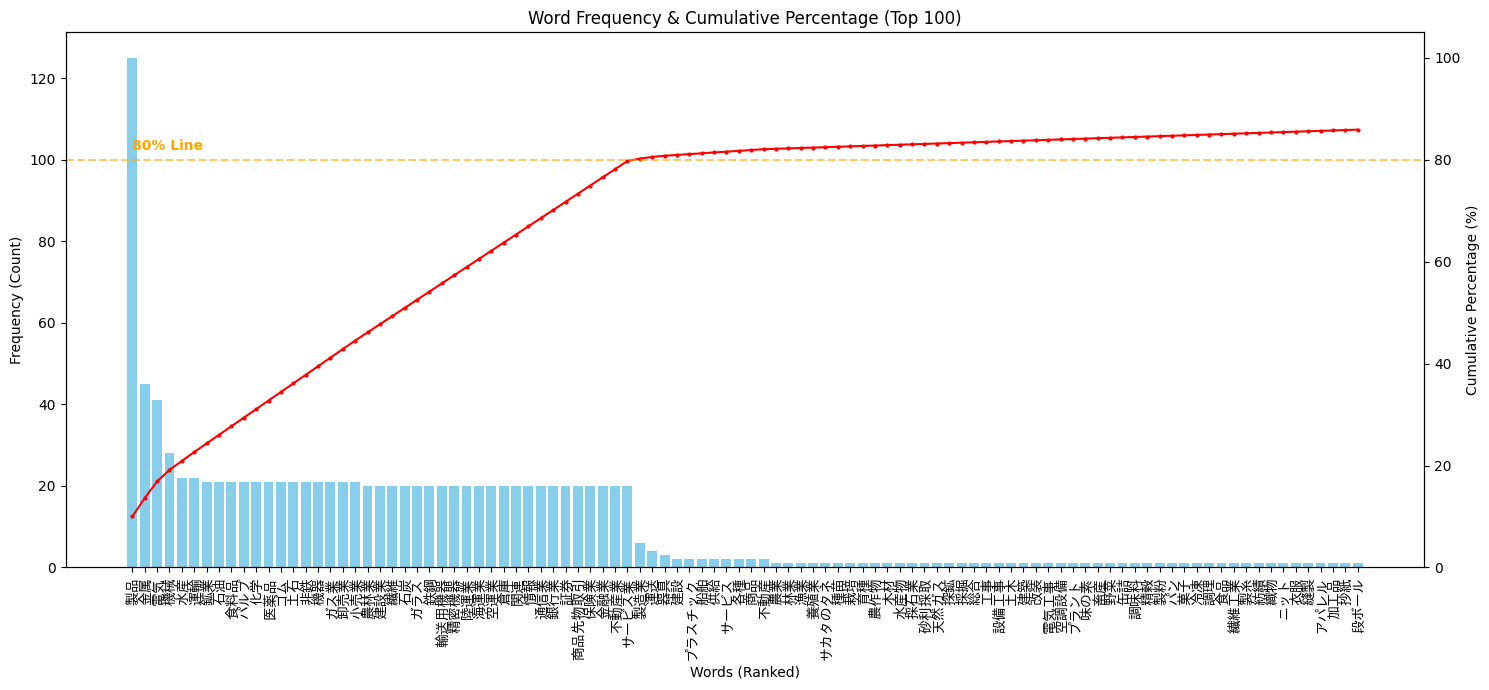

In [9]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# Linuxの標準フォント（MSゴシック）のパスを直接指定
# fc-listの結果から、確実にあるパスを指定
font_path = "/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 1. 単語の出現総数をカウント
all_words = " ".join(df["nouns"]).split()
word_counts = Counter(all_words)

# 2. データフレーム化してソート
counts_df = pd.DataFrame(word_counts.most_common(), columns=['word', 'count'])

# 3. 累積比率を計算
counts_df['cumulative_percent'] = counts_df['count'].cumsum() / counts_df['count'].sum() * 100

top_n = 100
plot_data = counts_df.head(top_n)

fig, ax1 = plt.subplots(figsize=(15, 7))

# 棒グラフ：単語の出現回数
ax1.bar(plot_data['word'], plot_data['count'], color='skyblue', label='Word Count')
xticks = np.arange(0, len(plot_data['word'].index), 1)
ax1.set_xticklabels(plot_data['word'], fontproperties=font_prop, rotation=90)
ax1.set_xticks(xticks)
ax1.set_ylabel('Frequency (Count)')
ax1.set_xlabel('Words (Ranked)')
ax1.tick_params(axis='x', rotation=90)

# 双子のアキシスを作成（折れ線用）
ax2 = ax1.twinx()
# 折れ線グラフ：累積比率
ax2.plot(plot_data['word'], plot_data['cumulative_percent'], color='red', marker='o', ms=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 105)

# 80%のラインに補助線を引く（パレートの法則の目安）
ax2.axhline(80, color='orange', linestyle='--', alpha=0.6)
ax2.text(0, 82, '80% Line', color='orange', fontweight='bold')

plt.title(f'Word Frequency & Cumulative Percentage (Top {top_n})')
plt.tight_layout()
plt.show()

In [10]:
label_names = ["水産・農林業", "鉱業","建設業","食料品","繊維製品","パルプ・紙", "化学", "医薬品", "石油・石炭製品", "ゴム製品", "ガラス・土石製品", "鉄鋼", "非鉄金属", "金属製品", "機械", "電気機器", "輸送用機器", "精密機器", "その他製品", "電気・ガス業", "陸運業", "海運業", "空運業", "倉庫・運輸関連業", "情報・通信業", "卸売業", "小売業", "銀行業", "証券、商品先物取引業", "保険業", "その他金融業", "不動産業", "サービス業"]
label_description = df["業種説明"]
print(label_description.dtype)

str


In [11]:
stop_word = ["分類","事業所","製造","総説","大分類","提供", "販売", "生産", "ため", "もの", "それぞれ", "商品", "製品", "業務", "実施","店舗","顧客"]


In [12]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

model_name = 'sentence-transformers/stsb-xlm-r-multilingual'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

custom_stop_words = stop_word
stop_ids = []

for word in custom_stop_words:
    ids = tokenizer.encode(word, add_special_tokens=False)
    stop_ids.extend(ids)

def encode_with_masking(text_list, model, tokenizer, stop_ids):
    model.eval()
    embeddings = []

    for text in text_list:
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)

        
        for s_id in stop_ids:
            inputs["attention_mask"] = inputs["attention_mask"] & (inputs['input_ids'] != s_id)
        with torch.no_grad():
            outputs = model(**inputs)

        token_embs = outputs.last_hidden_state
        mask = inputs["attention_mask"].unsqueeze(-1).expand(token_embs.size()).float()

        sum_embs = torch.sum(token_embs * mask, 1)
        sum_mask = torch.clamp(mask.sum(1), min=1e-9)
        vec = sum_embs / sum_mask
        embeddings.append(vec)

    return torch.cat(embeddings, dim=0)

master_embs_custom = encode_with_masking(df["業種説明"].tolist(), model, tokenizer, stop_ids)
master_embs_custom = F.normalize(master_embs_custom, p=2, dim=1)




/home/manaty/financial-contagion-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 753.96it/s]


In [13]:
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
#日本語対応のモデルをロード
model = SentenceTransformer('intfloat/multilingual-e5-base')
#33業種ラベルのエンコード (33, 768)
print(master_embs_custom)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 754.28it/s]


tensor([[ 0.0204, -0.0087,  0.1081,  ..., -0.0055, -0.0202, -0.0176],
        [ 0.0235,  0.0300, -0.0107,  ..., -0.0327,  0.0332, -0.0049],
        [ 0.0706,  0.0289,  0.0533,  ...,  0.0123, -0.0524,  0.0110],
        ...,
        [-0.0035, -0.0471, -0.0101,  ...,  0.0258, -0.0529,  0.0132],
        [ 0.0313, -0.0197,  0.0572,  ..., -0.0048,  0.0031, -0.0038],
        [ 0.0142,  0.0415,  0.1003,  ...,  0.0241, -0.0137,  0.0269]])


In [14]:
import torch
import numpy as np

# 1. NumPy配列をロード
test_embeddings_np = np.load('business_embeddings.npy')

# 2. PyTorch Tensorに変換
# torch.from_numpy() を使うのが最も効率的です
test_embeddings = torch.from_numpy(test_embeddings_np)

# 3. 必要に応じて型を合わせる
# モデルの出力（label_embsなど）が float32 の場合、型を合わせないと計算エラーになります
test_embeddings = test_embeddings.to(torch.float32)

# 4. もしGPUを使いたいなら
# test_embeddings = test_embeddings.to('cuda')

In [15]:
affinity = torch.matmul(test_embeddings, master_embs_custom.T)
final_33d_vector = F.softmax(affinity / 0.01, dim=1)

In [16]:
final_33d_vector.shape

torch.Size([4229, 33])

In [17]:
def clean_text_simple(text, stop_words):
    for word in stop_words:
        # 物理的に空白に置き換える
        text = text.replace(word, "")
    return text

# 業種説明をクレンジング
df['クレンジング説明'] = df['業種説明'].apply(lambda x: clean_text_simple(x, custom_stop_words))
df.head()

,業種名,業種説明,nouns,クレンジング説明
0,水産・農林業,水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農...,水産 農林業 水産 農林業 水産 農林業 水産 農林業 水産 農林業 水産 農林業 水産 農...,水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農林業。水産・農...
1,鉱業,鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱...,鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱業 鉱...,鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱業。鉱...
2,建設業,建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設...,建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設業 建設...,建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設業。建設...
3,食料品,食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料...,食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料品 食料...,食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料品。食料...
4,繊維製品,繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊維製品。繊...,繊維 製品 繊維 製品 繊維 製品 繊維 製品 繊維 製品 繊維 製品 繊維 製品 繊維 製...,繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊維。繊...


In [18]:
master_embs_clean = model.encode(df['クレンジング説明'].tolist(), convert_to_tensor=True)
master_embs_clean = F.normalize(master_embs_clean, p=2, dim=1)

In [19]:
affinity = torch.matmul(test_embeddings, master_embs_clean.T)
final_33d_vector = F.softmax(affinity / 0.01, dim=1)

In [20]:
final_33d_vector.shape

torch.Size([4229, 33])

In [21]:
# a は 1社分の33次元ベクトル(サカタのタネ916)#水産・農林業
# k=2 で上位2つを指定
values, indices = torch.topk(final_33d_vector[914], k=3)

first_idx = indices[0].item()  # 1位のインデックス
second_idx = indices[1].item() # 2位のインデックス
third_idx = indices[2].item() # 3位のインデックス
print("サカタのタネ")
print(f"第1位: {label_names[first_idx]} (スコア: {values[0].item():.4f})")
print(f"第2位: {label_names[second_idx]} (スコア: {values[1].item():.4f})")
print(f"第3位: {label_names[third_idx]} (スコア: {values[2].item():.4f})")

# a は 1社分の33次元ベクトル(キヤノン1808)#電気機器
# k=2 で上位2つを指定
values, indices = torch.topk(final_33d_vector[1806], k=3)

first_idx = indices[0].item()  # 1位のインデックス
second_idx = indices[1].item() # 2位のインデックス
third_idx = indices[2].item() # 3位のインデックス
print("キヤノン株式会社")
print(f"第1位: {label_names[first_idx]} (スコア: {values[0].item():.4f})")
print(f"第2位: {label_names[second_idx]} (スコア: {values[1].item():.4f})")
print(f"第3位: {label_names[third_idx]} (スコア: {values[2].item():.4f})")
# a は 1社分の33次元ベクトル(SBG3245)#電気機器
# k=2 で上位2つを指定
values, indices = torch.topk(final_33d_vector[3243], k=3)

first_idx = indices[0].item()  # 1位のインデックス
second_idx = indices[1].item() # 2位のインデックス
third_idx = indices[2].item() # 3位のインデックス
print("ソフトバンクグループ株式会社")
print(f"第1位: {label_names[first_idx]} (スコア: {values[0].item():.4f})")
print(f"第2位: {label_names[second_idx]} (スコア: {values[1].item():.4f})")
print(f"第3位: {label_names[third_idx]} (スコア: {values[2].item():.4f})")

# a は 1社分の33次元ベクトル(ファナック90)#機械
# k=2 で上位2つを指定
values, indices = torch.topk(final_33d_vector[88], k=3)

first_idx = indices[0].item()  # 1位のインデックス
second_idx = indices[1].item() # 2位のインデックス
third_idx = indices[2].item() # 3位のインデックス
print("ファナック")
print(f"第1位: {label_names[first_idx]} (スコア: {values[0].item():.4f})")
print(f"第2位: {label_names[second_idx]} (スコア: {values[1].item():.4f})")
print(f"第3位: {label_names[third_idx]} (スコア: {values[2].item():.4f})")

# a は 1社分の33次元ベクトル(フジクラ)#非鉄金属
# k=2 で上位2つを指定
values, indices = torch.topk(final_33d_vector[2836], k=3)

first_idx = indices[0].item()  # 1位のインデックス
second_idx = indices[1].item() # 2位のインデックス
third_idx = indices[2].item() # 3位のインデックス
print("株式会社フジクラ")
print(f"第1位: {label_names[first_idx]} (スコア: {values[0].item():.4f})")
print(f"第2位: {label_names[second_idx]} (スコア: {values[1].item():.4f})")
print(f"第3位: {label_names[third_idx]} (スコア: {values[2].item():.4f})")

# a は 1社分の33次元ベクトル(ソニーフィナンシャルグループ)#保険業
# k=2 で上位2つを指定
values, indices = torch.topk(final_33d_vector[2234], k=3)

first_idx = indices[0].item()  # 1位のインデックス
second_idx = indices[1].item() # 2位のインデックス
third_idx = indices[2].item() # 3位のインデックス
print("ソニーフィナンシャルグループ")
print(f"第1位: {label_names[first_idx]} (スコア: {values[0].item():.4f})")
print(f"第2位: {label_names[second_idx]} (スコア: {values[1].item():.4f})")
print(f"第3位: {label_names[third_idx]} (スコア: {values[2].item():.4f})")

# a は 1社分の33次元ベクトル(三井金属)#非鉄金属
# k=2 で上位2つを指定
values, indices = torch.topk(final_33d_vector[168], k=3)

first_idx = indices[0].item()  # 1位のインデックス
second_idx = indices[1].item() # 2位のインデックス
third_idx = indices[2].item() # 3位のインデックス
print("三井金属")
print(f"第1位: {label_names[first_idx]} (スコア: {values[0].item():.4f})")
print(f"第2位: {label_names[second_idx]} (スコア: {values[1].item():.4f})")
print(f"第3位: {label_names[third_idx]} (スコア: {values[2].item():.4f})")

# a は 1社分の33次元ベクトル(トヨタ自動車)#輸送用機器
# k=2 で上位2つを指定
values, indices = torch.topk(final_33d_vector[1792], k=3)

first_idx = indices[0].item()  # 1位のインデックス
second_idx = indices[1].item() # 2位のインデックス
third_idx = indices[2].item() # 3位のインデックス
print("トヨタ自動車")
print(f"第1位: {label_names[first_idx]} (スコア: {values[0].item():.4f})")
print(f"第2位: {label_names[second_idx]} (スコア: {values[1].item():.4f})")
print(f"第3位: {label_names[third_idx]} (スコア: {values[2].item():.4f})")


サカタのタネ
第1位: 水産・農林業 (スコア: 0.8801)
第2位: 倉庫・運輸関連業 (スコア: 0.0283)
第3位: 卸売業 (スコア: 0.0202)
キヤノン株式会社
第1位: 電気機器 (スコア: 0.2598)
第2位: その他製品 (スコア: 0.0860)
第3位: その他金融業 (スコア: 0.0655)
ソフトバンクグループ株式会社
第1位: サービス業 (スコア: 0.2478)
第2位: 食料品 (スコア: 0.1022)
第3位: 卸売業 (スコア: 0.0874)
ファナック
第1位: 機械 (スコア: 0.4083)
第2位: 非鉄金属 (スコア: 0.1650)
第3位: 水産・農林業 (スコア: 0.0706)
株式会社フジクラ
第1位: 非鉄金属 (スコア: 0.8473)
第2位: 倉庫・運輸関連業 (スコア: 0.0196)
第3位: 情報・通信業 (スコア: 0.0133)
ソニーフィナンシャルグループ
第1位: 保険業 (スコア: 0.3648)
第2位: その他金融業 (スコア: 0.2030)
第3位: 銀行業 (スコア: 0.1282)
三井金属
第1位: 非鉄金属 (スコア: 0.6097)
第2位: ガラス・土石製品 (スコア: 0.0862)
第3位: 鉄鋼 (スコア: 0.0477)
トヨタ自動車
第1位: 輸送用機器 (スコア: 0.3021)
第2位: 非鉄金属 (スコア: 0.1187)
第3位: その他金融業 (スコア: 0.0736)
